# Лабораторная работа "Алгоритм Гриффина-Лима"

### Цель работы:
Продемонстрировать работу алгоритма Гриффина-Лима на речевом сигнале. 

Импортируем необходимые библиотеки:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display
import os
from scipy.signal import lfilter

Выгружаем записанный звуковой файл:

In [2]:
filename = 'announcement.wav'
y, sr = librosa.load(filename, sr=None)

ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.4.

Для написания алгоритма возьмем коэффициент фильтра 0.97, размер окна 2048, сдвиг N/4:

In [3]:
alpha = 0.97
n_fft = 2048
hop_length = 512

y_pre = np.append(y[0], y[1:] - alpha * y[:-1])

In [4]:
print("Оригинальный сигнал:")
display(Audio(y_pre, rate=sr))

Оригинальный сигнал:


Вычисляем STFT, берем модуль, ччтобы получить Амплитудную спектрограмму

In [5]:
D_complex = librosa.stft(y_pre, n_fft=n_fft, hop_length=hop_length)

S_magnitude = np.abs(D_complex)

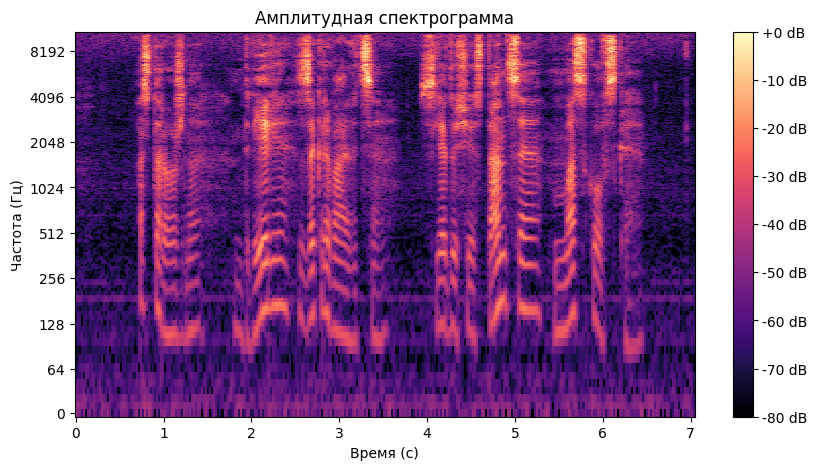

In [6]:
plt.figure(figsize=(10, 5))
librosa.display.specshow(librosa.amplitude_to_db(S_magnitude, ref=np.max),
                         sr=sr, hop_length=hop_length, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Амплитудная спектрограмма')
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.show()

Реализуем алгоритм Гриффина-Лима:

In [7]:
def griffin_lim(D, n_iter, n_fft, hop_length):

    random_phase_angle = 2 * np.pi * np.random.rand(*D.shape)
    random_phase_complex = np.exp(1j * random_phase_angle)
    
    D_star = D * random_phase_complex


    for i in range(n_iter):
        Xt = librosa.istft(D_star, hop_length=hop_length)   
        E = librosa.stft(Xt, n_fft=n_fft, hop_length=hop_length)
        eps = 1e-10
        Phi = E / (np.abs(E) + eps)
        D_star = D * Phi

    Xt_final = librosa.istft(D_star, hop_length=hop_length)
    Xout = np.real(Xt_final)
    
    return Xout

Вызываем написанную функцию

In [8]:
iters = 64
y_reconstructed = griffin_lim(S_magnitude, iters, n_fft, hop_length)

Применяем обратный фильтр:

In [9]:
y_final = lfilter([1], [1, -alpha], y_reconstructed)

Сохраняем полученный файл:

In [10]:
sf.write('reconstructed_output.wav', y_final, sr)

In [11]:
print("Восстановленный сигнал:")
display(Audio(y_final, rate=sr))

Восстановленный сигнал:


Построим спектрограмму для восстановленного сигнала:

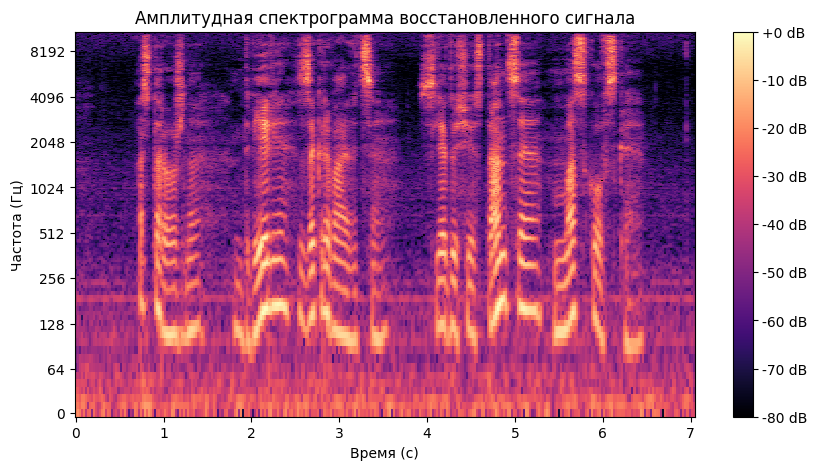

In [12]:
plt.figure(figsize=(10, 5))

D_final = librosa.stft(y_final, n_fft=2048, hop_length=512)

S_db_final = librosa.amplitude_to_db(np.abs(D_final), ref=np.max)

librosa.display.specshow(S_db_final, sr=sr, hop_length=512, x_axis='time', y_axis='log')

plt.colorbar(format='%+2.0f dB')
plt.title(f'Амплитудная спектрограмма восстановленного сигнала')
plt.xlabel("Время (с)")
plt.ylabel("Частота (Гц)")
plt.show()

Напишем функцию, которая будет вызывать наш алгоритм для разных значений параметров и сохранит полученные результаты:

In [13]:
def run_experiment(filename, alpha, n_fft, hop_fraction, n_iter, output_name):
    y, sr = librosa.load(filename, sr=None)
    
    if alpha > 0:
        y_proc = np.append(y[0], y[1:] - alpha * y[:-1])
    else:
        y_proc = y
        
    hop_length = int(n_fft / hop_fraction)
    
    D_complex = librosa.stft(y_proc, n_fft=n_fft, hop_length=hop_length)
    S_magnitude = np.abs(D_complex)
    
    y_rec = griffin_lim(S_magnitude, n_iter, n_fft, hop_length)
    
    if alpha > 0:
        y_final = lfilter([1], [1, -alpha], y_rec)
    else:
        y_final = y_rec
        
    out_path = f"results/{output_name}.wav"
    sf.write(out_path, y_final, sr)
    print(f"Saved: {out_path}")
    return y_final, sr

In [14]:
source_file = "announcement.wav"

Проведем эксперименты:

In [15]:
alphas = [0.0, 0.5, 0.97]
for a in alphas:
    name = f"Exp1_Alpha_{a}"
    run_experiment(source_file, alpha=a, n_fft=2048, hop_fraction=4, n_iter=32, output_name=name)

Saved: results/Exp1_Alpha_0.0.wav
Saved: results/Exp1_Alpha_0.5.wav
Saved: results/Exp1_Alpha_0.97.wav


In [16]:
Ns = [512, 1024, 2048, 4096]
for n in Ns:
    name = f"Exp2_N_{n}"
    run_experiment(source_file, alpha=0.97, n_fft=n, hop_fraction=4, n_iter=32, output_name=name)

Saved: results/Exp2_N_512.wav
Saved: results/Exp2_N_1024.wav
Saved: results/Exp2_N_2048.wav
Saved: results/Exp2_N_4096.wav


In [17]:
hops = [4, 2, 1] 
for h in hops:
    name = f"Exp3_Hop_N_div_{h}"
    run_experiment(source_file, alpha=0.97, n_fft=2048, hop_fraction=h, n_iter=32, output_name=name)

Saved: results/Exp3_Hop_N_div_4.wav
Saved: results/Exp3_Hop_N_div_2.wav
Saved: results/Exp3_Hop_N_div_1.wav


In [18]:
iters = [16, 32, 64, 128, 256]
for i in iters:
    name = f"Exp4_Iter_{i}"
    run_experiment(source_file, alpha=0.97, n_fft=2048, hop_fraction=4, n_iter=i, output_name=name)

Saved: results/Exp4_Iter_16.wav
Saved: results/Exp4_Iter_32.wav
Saved: results/Exp4_Iter_64.wav
Saved: results/Exp4_Iter_128.wav
Saved: results/Exp4_Iter_256.wav


Отобразим полученные результаты:

In [19]:
def display_results_group(group_name, file_pattern):
    print(f"\n {group_name} ")
    
    all_files = sorted(os.listdir('results'))
    group_files = [f for f in all_files if file_pattern in f]
    
    for filename in group_files:
        filepath = os.path.join('results', filename)
        y_display, sr_display = librosa.load(filepath, sr=None)
    
        print(f"Файл: {filename}")
        display(Audio(y_display, rate=sr_display))

display_results_group("Эксперимент 1: Параметр Alpha", "Exp1_Alpha")
display_results_group("Эксперимент 2: Размер окна (N)", "Exp2_N")
display_results_group("Эксперимент 3: Сдвиг окна (Hop)", "Exp3_Hop")
display_results_group("Эксперимент 4: Итерации", "Exp4_Iter")


 Эксперимент 1: Параметр Alpha 
Файл: Exp1_Alpha_0.0.wav


Файл: Exp1_Alpha_0.5.wav


Файл: Exp1_Alpha_0.97.wav



 Эксперимент 2: Размер окна (N) 
Файл: Exp2_N_1024.wav


Файл: Exp2_N_2048.wav


...


 Эксперимент 4: Итерации 
Файл: Exp4_Iter_128.wav


Файл: Exp4_Iter_16.wav


Файл: Exp4_Iter_256.wav


Файл: Exp4_Iter_32.wav


Файл: Exp4_Iter_64.wav


### Выводы

1. Зависимость качества востановленного аудио от наличия фильтра:
   При отсутствии фильтра звук становится немного глуховатым, при использовании фильтра с alpha = 0.97 звук становится более звонким.
   
2. Зависимость качества востановленного аудио от размера окна N:
   При большом значении N (4096) возникает эффект эха и звона.
   При слишком маленьком значении N (512) голос становится немного роботизированным
   Вероятно, оптимальное значение - 1024

   
3. Зависимость качества востановленного аудио от сдвига:
   h = N: ужасное качество, алгоритм не работает
   h = N/2: становится лучше, однако слышны артефакты
   h = N/4: хорошее качество

   
4. Зависимость качества востановленного аудио от количества итераций:
   при i = 16 голос немного дрожит
   при увеличении количество итераций качество немного улучшается, однако разница между 64, 128 и 256 почти не заметна